In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import networkx as nx
from pgmpy.inference import VariableElimination
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("heart.csv")
print("First Five Records")
print(df.head())


First Five Records
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak
0   63    1   3       145   233    1        0      150      0      2.3
1   37    1   2       130   250    0        1      187      0      3.5
2   41    0   1       130   204    0        0      172      0      1.4
3   56    1   1       120   236    0        1      178      0      0.8
4   57    0   0       120   354    0        1      163      1      0.6


In [3]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (303, 10)


In [4]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
dtype: int64


In [5]:
print("\nDataset Information")
print(df.info())



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
dtypes: float64(1), int64(9)
memory usage: 23.8 KB
None


In [6]:
print("\nStatistical Summary")
print(df.describe())



Statistical Summary
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak  
count  303.000000  303.000000  303.000000  303.000000  
mean     0.528053  149.646865    0.326733    1.039604  
std      0.525860   22.905161    0.469794    1.161075  
min      0.000000   71.00

In [7]:
print("\nColumns in dataset:")
print(df.columns)



Columns in dataset:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak'],
      dtype='object')


In [13]:

df['target'] = df['exang']

print("Target column created successfully!")
print("Target values:", sorted(df['target'].unique()))

Target column created successfully!
Target values: [np.int64(0), np.int64(1)]


In [12]:
print("\nCreated 'target' from 'exang'. Values:",
      sorted(df['target'].unique()))


Created 'target' from 'exang'. Values: [np.int64(0), np.int64(1)]


In [9]:

if df['age'].nunique() > 10:
    df['age'] = pd.cut(df['age'], bins=5, labels=False)

if df['chol'].nunique() > 10:
    df['chol'] = pd.cut(df['chol'], bins=5, labels=False)



In [14]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE


In [15]:
model = DiscreteBayesianNetwork([
    ('age', 'target'),
    ('sex', 'target'),
    ('cp', 'target'),
 
   ('exang', 'target'),
    ('target', 'restecg'),
    ('target', 'chol')
])


In [16]:
model.fit(df, estimator=DiscreteMLE())
print("\nBayesian Network Created Successfully")



Bayesian Network Created Successfully


In [17]:
print("\nCPD of AGE\n")
print(model.get_cpds('age'))



CPD of AGE

+--------+-----------+
| age(0) | 0.039604  |
+--------+-----------+
| age(1) | 0.234323  |
+--------+-----------+
| age(2) | 0.320132  |
+--------+-----------+
| age(3) | 0.349835  |
+--------+-----------+
| age(4) | 0.0561056 |
+--------+-----------+


In [18]:
print("\nCPD of SEX\n")
print(model.get_cpds('sex'))



CPD of SEX

+--------+----------+
| sex(0) | 0.316832 |
+--------+----------+
| sex(1) | 0.683168 |
+--------+----------+


In [19]:
print("\nCPD of EXANG\n")
print(model.get_cpds('exang'))



CPD of EXANG

+----------+----------+
| exang(0) | 0.673267 |
+----------+----------+
| exang(1) | 0.326733 |
+----------+----------+


In [20]:
print("\nCPD of TARGET\n")
print(model.get_cpds('target'))



CPD of TARGET

+-----------+----------+----------+----------+----------+-----+----------+----------+----------+----------+----------+
| age       | age(0)   | age(0)   | age(0)   | age(0)   | ... | age(4)   | age(4)   | age(4)   | age(4)   | age(4)   |
+-----------+----------+----------+----------+----------+-----+----------+----------+----------+----------+----------+
| cp        | cp(0)    | cp(0)    | cp(0)    | cp(0)    | ... | cp(2)    | cp(3)    | cp(3)    | cp(3)    | cp(3)    |
+-----------+----------+----------+----------+----------+-----+----------+----------+----------+----------+----------+
| exang     | exang(0) | exang(0) | exang(1) | exang(1) | ... | exang(1) | exang(0) | exang(0) | exang(1) | exang(1) |
+-----------+----------+----------+----------+----------+-----+----------+----------+----------+----------+----------+
| sex       | sex(0)   | sex(1)   | sex(0)   | sex(1)   | ... | sex(1)   | sex(0)   | sex(1)   | sex(0)   | sex(1)   |
+-----------+----------+--------

In [21]:
print("\nCPD of CHOLESTEROL\n")
print(model.get_cpds('chol'))



CPD of CHOLESTEROL

+---------+----------------------+----------------------+
| target  | target(0)            | target(1)            |
+---------+----------------------+----------------------+
| chol(0) | 0.28921568627450983  | 0.26262626262626265  |
+---------+----------------------+----------------------+
| chol(1) | 0.5784313725490197   | 0.5757575757575758   |
+---------+----------------------+----------------------+
| chol(2) | 0.11274509803921569  | 0.15151515151515152  |
+---------+----------------------+----------------------+
| chol(3) | 0.014705882352941176 | 0.010101010101010102 |
+---------+----------------------+----------------------+
| chol(4) | 0.004901960784313725 | 0.0                  |
+---------+----------------------+----------------------+


In [22]:
print("\nModel Check")

is_valid = model.check_model()

print("Model Valid:", is_valid)

if not is_valid:
    raise ValueError(
        "Model structure or CPDs are invalid.")



Model Check
Model Valid: True


In [23]:
print("\nNodes")
print(list(model.nodes()))

print("\nEdges")
print(list(model.edges()))



Nodes
['age', 'target', 'sex', 'cp', 'exang', 'restecg', 'chol']

Edges
[('age', 'target'), ('target', 'restecg'), ('target', 'chol'), ('sex', 'target'), ('cp', 'target'), ('exang', 'target')]


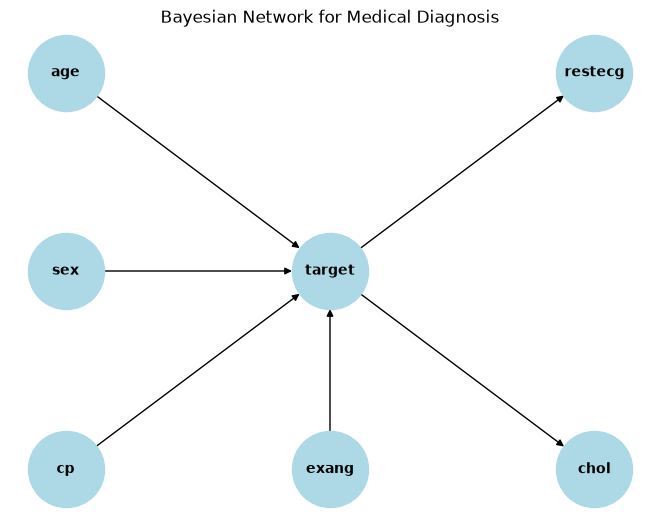

In [30]:
pos = {
    "age": (0, 2),
    "sex": (0, 1),
    "cp": (0, 0),
    "target": (2, 1),
    "exang": (2, 0),
    "restecg": (4, 2),
    "chol": (4, 0)
}
nx.draw(
    model,
    pos=pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    arrows=True
)

plt.title("Bayesian Network for Medical Diagnosis")
plt.show()

In [33]:
print("\n" + "=" * 50)
print("Bayesian Network Inference")
print("=" * 50)

inference = VariableElimination(model)

print("\nQuery 1: Prior Probability of Target")

result_prior = inference.query(
    variables=["target"]
)

print(result_prior)


Bayesian Network Inference

Query 1: Prior Probability of Target
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.7009 |
+-----------+---------------+
| target(1) |        0.2991 |
+-----------+---------------+


In [34]:
evidence = {
    "age": 2,
    "sex": 1,
    "cp": 2}

print(
    "\nQuery 2: Probability of Target "
    "Given Patient Information")

try:

    result = inference.query(
        variables=["target"],
        evidence=evidence)

    print("\nMedical Diagnosis Prediction")
    print("Evidence:", evidence)
    print(result)

except Exception as e:

    print("\nInference could not be performed.")
    print("Reason:", e)




Query 2: Probability of Target Given Patient Information

Medical Diagnosis Prediction
Evidence: {'age': 2, 'sex': 1, 'cp': 2}
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.6733 |
+-----------+---------------+
| target(1) |        0.3267 |
+-----------+---------------+


In [35]:
print(
    "\nQuery 3: Given restecg = 1, "
    "What is P(target)?")

try:

    result_3 = inference.query(
        variables=["target"],
        evidence={"restecg": 1})

    print(result_3)

except Exception as e:

    print("Reason:", e)



Query 3: Given restecg = 1, What is P(target)?
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.7424 |
+-----------+---------------+
| target(1) |        0.2576 |
+-----------+---------------+


In [36]:
print(
    "\nQuery 4: Given chol = 4, "
    "What is P(target)?")

try:

    result_4 = inference.query(
        variables=["target"],
        evidence={"chol": 4})

    print(result_4)

except Exception as e:

    print("Reason:", e)



Query 4: Given chol = 4, What is P(target)?
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        1.0000 |
+-----------+---------------+
| target(1) |        0.0000 |
+-----------+---------------+


In [37]:
print("\nDiagnosis Inference Complete.")




Diagnosis Inference Complete.
